# Cardiovascular Outcomes and Race/Ethnicity in US Adults
## BRFSS 2024 — Weighted Logistic Regression Analysis

---

## 1. Project Overview and Research Question

**Research question.** Is there a measurable association between race/ethnicity and cardiovascular outcomes (primarily self-reported heart attack) in US adults, after adjusting for key clinical risk factors (diabetes status, smoking status, age, sex)?

**Data.** CDC Behavioral Risk Factor Surveillance System (BRFSS) 2024, public-use file. ~458,000 adult respondents, 301 variables; this analysis subsets to 25 analytical columns.

**Primary outcome.** `CVDINFR4` — *"(Ever told) you had a heart attack, also called a myocardial infarction?"* (self-report, Yes/No).

**Primary exposure.** `_IMPRACE` — CDC imputed race/ethnicity, 6 categories (White, Black, Asian, American Indian/Alaskan Native, Hispanic, Other).

**Adjustment variables.** `diabetes_status` (engineered from `DIABETE4`), `smoking_status` (engineered from `SMOKE100` + `SMOKDAY2`), `_AGEG5YR` (5-year age group), `SEXVAR`.

**Survey design.** `_LLCPWT` (final weights), `_STSTR` (strata), `_PSU` (primary sampling units). The primary model uses normalized frequency weights and cluster-robust standard errors on `_PSU`.

**Framing note.** Race is modeled here as a social/structural variable, not a biological one. Adjusted coefficients represent residual association after controlling for variables (diabetes, smoking, etc.) that are themselves shaped by racialization; unconditional disparities are therefore larger than the conditional estimates reported here. See Section 11.


## 2. Setup

Mount Google Drive and import all libraries used in the notebook in a single place. Every subsequent cell should run from a fresh kernel restart provided this cell has run. Google Drive and Google's BigQuery used to handle large files size.


In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


## 3. Data Loading and Variable Selection

BRFSS 2024 ships as a 301-column file. We subset at read time to 25 analytical columns: the CVD outcomes, the race/ethnicity exposure, demographic and clinical risk factors, and the survey design variables. Keeping the subset explicit at the load step documents the analytical scope and keeps memory modest.


In [3]:
#Defining the subset: BRFSS is 301 columns with over 401k rows. We are looking for relevant columns and used codebook to determine relevant columns

analysis_col = [
# ---Outcomes---
'CVDINFR4', # had heart attack
'CVDCRHD4', # had angina or CHD
'CVDSTRK3', # stroke
'_MICHD', # Caluated: MI or coronary heart disease

#---Race/Ethnicity---
'_IMPRACE', # CDC imputed race
'_RACE', # Computed race
'_HISPANC', # Hispanic/Latino

#--- Control Demographics ---
'SEXVAR', # Sex of respondent
'_AGEG5YR', # Age group
'_AGE80', # Age top coded as 80
'EDUCA', # Education level
'INCOME3', # Annual household income

#--- Control Clinical Risk Factors ---
'DIABETE4', # diabetes
'SMOKE100', # smoked at least 100 cigarettes in life
'_BMI5CAT', # BMI Category
'_BMI5', # Continuous BMI
'SMOKDAY2', # smoking frequency
'EXERANY2', # exercise in past 30 days
'CHCCOPD3', # COPD
'CHCKDNY2', # Kidney disease
'ADDEPEV3', # Adult depression

#--- GEOGRAPHY ---
'_STATE', # State of residence

#--- Survey methods ---
'_LLCPWT', # Final combined phone call weights
'_STSTR', # Stratification variable
'_PSU', # Public use survey

]

df = pd.read_csv("/content/gdrive/MyDrive/BRFSS_2024.csv", usecols=analysis_col)

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

Shape: (457670, 25)
Memory: 91.5 MB


Confirmed shape 457,670 × 25


## 4. Codebook Reference - **All**

Response codes for every variable used in the analysis. Values not listed (e.g., `7`=Don't know, `9`=Refused) are treated as missing during recoding (Section 6). Source: *BRFSS 2024 Codebook Report, Overall Version — USCODE24_LLCP_082125*.

### Outcomes

| Variable | Question | Codes |
|---|---|---|
| `CVDINFR4` | Ever had a heart attack (MI)? | 1=Yes, 2=No, 7=DK, 9=Refused |
| `CVDCRHD4` | Ever had angina or coronary heart disease? | 1=Yes, 2=No, 7=DK, 9=Refused |
| `CVDSTRK3` | Ever had a stroke? | 1=Yes, 2=No, 7=DK, 9=Refused |
| `_MICHD` | *Calculated:* MI or CHD | 1=Yes, 2=No |

### Race / ethnicity (primary exposure)

`_IMPRACE` — CDC-imputed race/ethnicity. The codebook lists:

| Code | Label |
|---|---|
| 1 | White, Non-Hispanic |
| 2 | Black, Non-Hispanic |
| 3 | Asian, Non-Hispanic |
| 4 | American Indian / Alaskan Native, Non-Hispanic |
| 5 | Hispanic |
| 6 | Other Race, Non-Hispanic |

### Clinical risk factors

| Variable | Meaning | Codes |
|---|---|---|
| `DIABETE4` | Ever told you had diabetes? | 1=Yes, 2=Gestational only, 3=No, 4=Pre-diabetic, 7/9=DK/Refused |
| `SMOKE100` | Smoked at least 100 cigarettes in life? | 1=Yes, 2=No, 7/9=DK/Refused |
| `SMOKDAY2` | Current smoking frequency (if SMOKE100=Yes) | 1=Every day, 2=Some days, 3=Not at all, 7/9=DK/Refused |
| `_BMI5` | Continuous BMI × 100 | integer, multiply by 0.01 |
| `_BMI5CAT` | BMI category | 1=Underweight, 2=Normal, 3=Overweight, 4=Obese |

### Demographics / SES

| Variable | Meaning | Codes |
|---|---|---|
| `SEXVAR` | Sex | 1=Male, 2=Female |
| `_AGEG5YR` | Age group (5-year) | 1–13 = 18–24 through 80+; 14=DK/Refused/Missing |
| `_AGE80` | Age, top-coded at 80 | continuous |
| `EDUCA` | Highest grade / year of school completed | 1–6 = levels; 9=Refused |
| `INCOME3` | Annual household income | 1–11 = bands; 77=DK, 99=Refused |

### Survey design

| Variable | Role |
|---|---|
| `_LLCPWT` | Final combined phone-call weight |
| `_STSTR` | Stratification variable |
| `_PSU` | Primary sampling unit (cluster ID) |


## 5. Data Missingness Audit **Agee**

Before any recoding, we inspect raw value distributions, overall missingness, and two specific missingness questions:

1. *Skip logic*: is the high NaN rate on `SMOKDAY2` explained by the survey branching (only asked of ever-smokers)?
2. *Informative missingness*: do BMI-missing respondents differ systematically from BMI-reporting respondents on race or outcome? (relevant to decisions about whether BMI can be used as a covariate).


### 5.1 Raw distributions for key variables - **Agee**


In [4]:
# Look at raw value counts for three key variables
print("=== CVDINFR4 (Heart Attack) ===")
print(df['CVDINFR4'].value_counts(dropna=False).sort_index())

print("\n=== _IMPRACE (Race) ===")
print(df['_IMPRACE'].value_counts(dropna=False).sort_index())

print("\n=== DIABETE4 (Diabetes) ===")
print(df['DIABETE4'].value_counts(dropna=False).sort_index())

=== CVDINFR4 (Heart Attack) ===
CVDINFR4
1.0     26672
2.0    427883
7.0      2857
9.0       256
NaN         2
Name: count, dtype: int64

=== _IMPRACE (Race) ===
_IMPRACE
1.0    336908
2.0     35559
3.0     12760
4.0      6621
5.0     48961
6.0     16861
Name: count, dtype: int64

=== DIABETE4 (Diabetes) ===
DIABETE4
1.0     65809
2.0      3395
3.0    376125
4.0     11307
7.0       798
9.0       232
NaN         4
Name: count, dtype: int64


### 5.2 Overall missingness audit - **Agee**


In [5]:
# NaN accross subset to see if there is some truth in missing values
missing_audit = pd.DataFrame({
    'total': df.shape[0],
    'nan_count': df.isna().sum(),
    'nan_pct': (df.isna().sum() / df.shape[0] * 100).round(2),
    'unique_values': df.nunique(),
    'value_counts': [sorted(df[c].dropna().unique().tolist()) for c in df.columns]
})

print(missing_audit[['nan_count', 'nan_pct', 'unique_values', 'value_counts']].to_string())

          nan_count  nan_pct  unique_values                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

### 5.3 High-missingness variables - **Agee**

Only four variables exceed 5% missingness before recoding: the two smoking variables and the two BMI variables.


In [6]:
high_nan = missing_audit[missing_audit['nan_pct'] > 5].index.tolist()
print("Variables with >5% NaN:", high_nan)

Variables with >5% NaN: ['SMOKE100', 'SMOKDAY2', '_BMI5', '_BMI5CAT']


### 5.4 `SMOKDAY2` skip-logic check - **Agee**

`SMOKDAY2` is ~64% missing. This should be driven by survey skip logic: the question is only asked of respondents who answered `SMOKE100=1` (smoked ≥100 cigarettes in life). We verify by cross-tabulating `SMOKE100` among `SMOKDAY2`-missing rows.


In [7]:
print(df[df['SMOKDAY2'].isna()]['SMOKE100'].value_counts(dropna=False))

SMOKE100
2.0    258956
NaN     28860
7.0      2062
9.0       550
1.0       166
Name: count, dtype: int64


`SMOKE100=2` (never-smoker) accounts for ~259k of the missing `SMOKDAY2` rows. This confirms the pattern skip logic would produce. This also determined how we engineer `smoking_status` in Section 6: `SMOKDAY2`=NaN for never-smokers is **not** true missingness.


### 5.5 BMI raw values and category distribution - **Agee**


In [8]:
print("=== _BMI5 (Continuous BMI) ===")
print((df['_BMI5']/100).value_counts(dropna=False).sort_index().head(20))

print("\n=== _BMI5CAT (BMI Category) ===")
print(df['_BMI5CAT'].value_counts(dropna=False).sort_index())

=== _BMI5 (Continuous BMI) ===
_BMI5
12.00    1
12.05    2
12.08    1
12.11    5
12.13    1
12.16    1
12.17    1
12.19    1
12.20    2
12.21    3
12.22    1
12.26    1
12.27    2
12.30    1
12.31    1
12.36    1
12.40    5
12.41    1
12.44    2
12.48    5
Name: count, dtype: int64

=== _BMI5CAT (BMI Category) ===
_BMI5CAT
1.0      7377
2.0    121053
3.0    146563
4.0    139640
NaN     43037
Name: count, dtype: int64


`_BMI5` is stored as BMI × 100 (integer). We'll divide by 100 during recoding so values are on the usual scale.


### 5.6 Informative missingness: BMI - **Agee**

BMI is ~9% missing. If the missingness were random with respect to race and outcome, we could ignore it. The check below compares racial composition and heart-attack prevalence between BMI-reporting and BMI-missing respondents.


In [9]:

# Are the BMI-missing respondents different on race and CVD outcome?
bmi_present = df[df['_BMI5CAT'].notna()]
bmi_missing = df[df['_BMI5CAT'].isna()]

print("=== Race Distribution ===")
print(f"{'Race Code':<12} {'BMI Present':>14} {'BMI Missing':>14} {'Difference':>12}")
print("-" * 54)

# True is coded as "1", and False is "0", looking for the proportion of where BMI_present or BMI missing is 1 (counting number of trues). The mean function works since one can count the number of trues vs falses. Also, it is worth noting that BMI Present vs BMI Missing are two different populations.
for race in sorted(df['_IMPRACE'].dropna().unique()):
    present_pct = (bmi_present['_IMPRACE'] == race).mean()
    missing_pct = (bmi_missing['_IMPRACE'] == race).mean()
    diff = missing_pct - present_pct
    print(f"{race:<12.0f} {present_pct:>13.1%} {missing_pct:>13.1%} {diff:>+11.1%}")

print("\n=== Heart Attack Rate ===")
print(f"{'Response':<12} {'BMI Present':>14} {'BMI Missing':>14} {'Difference':>12}")
print("-" * 54)
#
for val in [1.0, 2.0, 7.0, 9.0]:
    present_pct = (bmi_present['CVDINFR4'] == val).mean()
    missing_pct = (bmi_missing['CVDINFR4'] == val).mean()
    diff = missing_pct - present_pct
    label = {1.0: 'Yes', 2.0: 'No', 7.0: "Don't know", 9.0: 'Refused'}[val]
    print(f"{label:<12} {present_pct:>13.1%} {missing_pct:>13.1%} {diff:>+11.1%}")

=== Race Distribution ===
Race Code       BMI Present    BMI Missing   Difference
------------------------------------------------------
1                    74.4%         65.8%       -8.7%
2                     7.6%          9.1%       +1.5%
3                     2.7%          3.7%       +1.0%
4                     1.5%          1.4%       -0.1%
5                    10.1%         16.4%       +6.3%
6                     3.7%          3.6%       -0.0%

=== Heart Attack Rate ===
Response        BMI Present    BMI Missing   Difference
------------------------------------------------------
Yes                   6.0%          4.4%       -1.6%
No                   93.4%         94.2%       +0.8%
Don't know            0.6%          1.1%       +0.5%
Refused               0.0%          0.3%       +0.3%


The BMI-missing group is relatively under-White (−8.7 pp) and over-Hispanic (+6.3 pp), and has a lower reported heart-attack rate. This is non-ignorable missingness on dimensions directly relevant to the research question — a reason BMI is **not** included as a covariate in the primary model. Age, sex, and smoking have near-zero missingness and are retained.


## 6. Recoding and Feature Construction - **Flanders**

Decisions applied below:

- **Sentinel values** (`7`=DK, `9`=Refused; `77`/`99` for income) → `NaN` across all variables.
- **Gestational diabetes** (`DIABETE4=2`) → `NaN`, since it is not clinically equivalent to Type 1/2 diabetes for cardiovascular risk-factor analysis.
- **`diabetes_status`**: 3-level categorical: 0 = no diabetes, 1 = diabetic, 2 = pre-diabetic.
- **`smoking_status`**: engineered from `SMOKE100` + `SMOKDAY2` to give a single 4-level variable (1 = never, 2 = former, 3 = some days, 4 = every day) rather than using either input variable alone.
- **`_BMI5`** rescaled to the usual BMI scale (÷100). Retained in the dataset for descriptive purposes but **not** used as a covariate in modelling (see Section 5.6).
- **Race (`_IMPRACE`)**: the six codebook values (1=White, 2=Black, 3=Asian, 4=American Indian/Alaskan Native, 5=Hispanic, 6=Other) are all valid; no recoding needed.


In [10]:
# ── CVD OUTCOMES ──────────────────────────────────────────────
# 1=Yes, 2=No, 7/9=Don't know/Refused → NaN
for col in ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3']:
    df[col] = df[col].replace({7.0: np.nan, 9.0: np.nan})

# _MICHD is a calculated variable — only NaN needs handling
# 1=MI or CHD, 2=No

# ── RACE ──────────────────────────────────────────────────────
# _IMPRACE: 1=White, 2=Black, 3=Asian,
#           4=American Indian/Alaskan Native, 5=Hispanic, 6=Other
# All values are valid — no recoding needed.

# ── DIABETES ──────────────────────────────────────────────────
# Decision: treat as 3 distinct categories
# 1=Diabetic, 3=No diabetes, 4=Pre-diabetic
# 2=Gestational only → NaN (not clinically equivalent to diabetes)
# 7/9 → NaN
df['diabetes_status'] = df['DIABETE4'].replace({
    1.0: 1,    # Diabetic
    2.0: np.nan,  # Gestational only — excluded
    3.0: 0,    # No diabetes
    4.0: 2,    # Pre-diabetic
    7.0: np.nan,
    9.0: np.nan
})

# ── SMOKING ───────────────────────────────────────────────────
# Engineer a single smoking_status variable from SMOKE100 + SMOKDAY2
# Rather than use either variable alone
# 1=Never, 2=Former, 3=Some days, 4=Every day
df['SMOKE100'] = df['SMOKE100'].replace({7.0: np.nan, 9.0: np.nan})
df['SMOKDAY2'] = df['SMOKDAY2'].replace({7.0: np.nan, 9.0: np.nan})

conditions = [
    df['SMOKE100'] == 2,
    (df['SMOKE100'] == 1) & (df['SMOKDAY2'] == 3),
    (df['SMOKE100'] == 1) & (df['SMOKDAY2'] == 2),
    (df['SMOKE100'] == 1) & (df['SMOKDAY2'] == 1),
]
choices = [1, 2, 3, 4]
df['smoking_status'] = np.select(conditions, choices, default=np.nan)

# ── BMI ───────────────────────────────────────────────────────
# Divide continuous BMI by 100 (BRFSS stores as integer × 100)
df['_BMI5'] = df['_BMI5'] / 100

# _BMI5CAT: 1=Underweight, 2=Normal, 3=Overweight, 4=Obese
# All four categories valid — NaN stays NaN (informative missingness noted)

# ── SIMPLE YES/NO RISK FACTORS ────────────────────────────────
# 1=Yes, 2=No, 7/9 → NaN
for col in ['EXERANY2', 'CHCCOPD3', 'CHCKDNY2', 'ADDEPEV3']:
    df[col] = df[col].replace({7.0: np.nan, 9.0: np.nan})

# ── DEMOGRAPHICS ──────────────────────────────────────────────
# SEXVAR: 1=Male, 2=Female — no missing values, no recoding needed

# _AGEG5YR: 1-13 = age groups 18-24 through 80+
# 14 = Don't know/Refused/Missing → NaN
df['_AGEG5YR'] = df['_AGEG5YR'].replace({14.0: np.nan})

# _AGE80: continuous age, top-coded at 80 — all values valid

# EDUCA: 1-6 = education levels, 9=Refused → NaN
df['EDUCA'] = df['EDUCA'].replace({9.0: np.nan})

# INCOME3: 1-11 = income levels
# 77=Don't know, 99=Refused → NaN
df['INCOME3'] = df['INCOME3'].replace({77.0: np.nan, 99.0: np.nan})


print(f"Shape: {df.shape}")
print(f"\nNull counts after recoding:")
print(df.isna().sum())


Shape: (457670, 27)

Null counts after recoding:
_STATE                  0
_PSU                    0
SEXVAR                  0
EXERANY2             1315
CVDINFR4             3115
CVDCRHD4             4578
CVDSTRK3             1452
CHCCOPD3             2174
ADDEPEV3             2664
CHCKDNY2             1979
DIABETE4                4
EDUCA                2363
INCOME3             87423
SMOKE100            31472
SMOKDAY2           290978
_STSTR                  0
_IMPRACE                0
_LLCPWT                 0
_MICHD               5206
_HISPANC                0
_RACE                   0
_AGEG5YR             8310
_AGE80                  0
_BMI5               43037
_BMI5CAT            43037
diabetes_status      4429
smoking_status      32022
dtype: int64


Income (`INCOME3`) is ~20% missing after recoding; this is the largest remaining gap. This is why SES is held out of the primary model and introduced only in Section 10 as a sensitivity analysis.


### 6.1 Recoding verification - **Flanders**


In [11]:
# Verify DIABETE4 recoding — should only show 0, 1, 2 and NaN
print(df['DIABETE4'].value_counts(dropna=False).sort_index())

# Verify smoking_status — should only show 1, 2, 3, 4 and NaN
print(df['smoking_status'].value_counts(dropna=False).sort_index())

DIABETE4
1.0     65809
2.0      3395
3.0    376125
4.0     11307
7.0       798
9.0       232
NaN         4
Name: count, dtype: int64
smoking_status
1.0    258956
2.0    119598
3.0     13976
4.0     33118
NaN     32022
Name: count, dtype: int64


`diabetes_status` shows the expected three levels (0, 1, 2) with gestational-only responses dropped. `smoking_status` shows all four engineered levels, with NaN concentrated where both `SMOKE100` and `SMOKDAY2` were uninformative.


## 7. Descriptive Analysis - **Flanders**

Unadjusted prevalence plots. These are only exploratory and do not control for age, sex, or smoking, and they do not use survey weights. They indicate *sample* patterns rather than population estimates. They motivate the adjusted model in Section 8.


### 7.1 Heart attack prevalence by race - **Flanders**


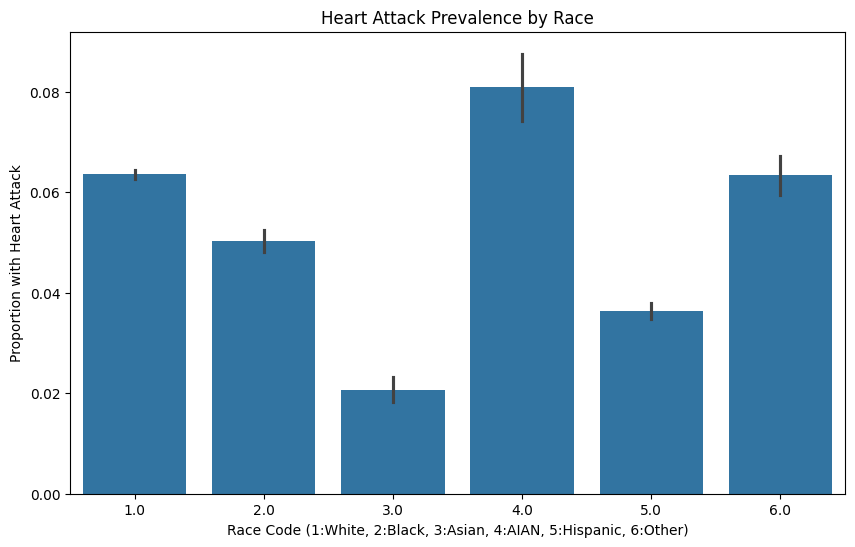

In [12]:
# Calculate Heart Attack rates by Race
# 1.0 is 'Yes' for heart attack
df_plot = df.dropna(subset=['CVDINFR4', '_IMPRACE'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='_IMPRACE', y=(df_plot['CVDINFR4'] == 1.0))
plt.title('Heart Attack Prevalence by Race')
plt.ylabel('Proportion with Heart Attack')
plt.xlabel('Race Code (1:White, 2:Black, 3:Asian, 4:AIAN, 5:Hispanic, 6:Other)')
plt.show()

Unadjusted sample prevalence of heart attack varies meaningfully by race.


### 7.2 Heart attack prevalence by diabetes status - **Flanders**


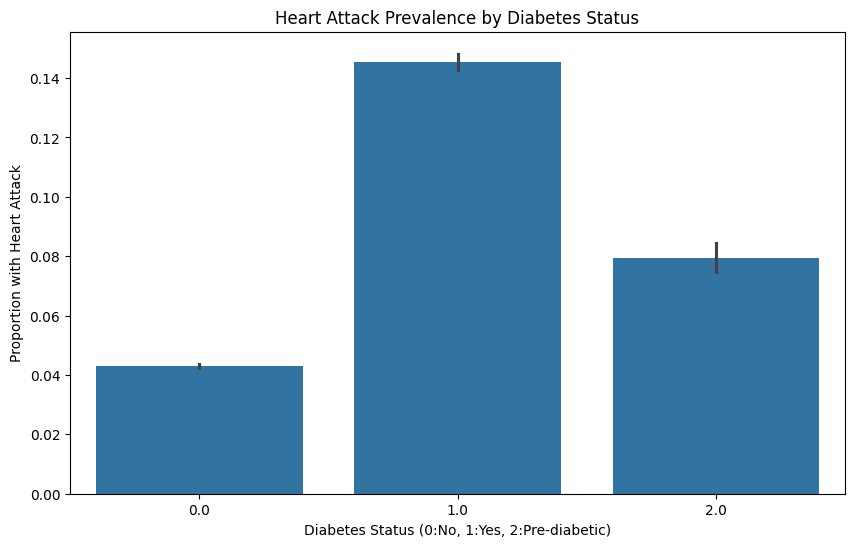

In [13]:
# Calculate Heart Attack rates by Diabetes Status
df_plot_diab = df.dropna(subset=['CVDINFR4', 'diabetes_status'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot_diab, x='diabetes_status', y=(df_plot_diab['CVDINFR4'] == 1.0))
plt.title('Heart Attack Prevalence by Diabetes Status')
plt.ylabel('Proportion with Heart Attack')
plt.xlabel('Diabetes Status (0:No, 1:Yes, 2:Pre-diabetic)')
plt.show()

Heart-attack prevalence is substantially higher in diabetic respondents than in non-diabetics, with pre-diabetics in between. This is consistent with established clinical literature.


### 7.3 Other cardiovascular outcomes — overall prevalence **Flanders**


In [14]:

# Summary of other cardiovascular outcomes
other_cvd = ['CVDSTRK3', 'CVDCRHD4', '_MICHD']

print("=== Prevalence of Other Cardiovascular Issues ===")
# Ensuring the dataframe exists before proceeding
if 'df' in globals():
    for col in other_cvd:
        if col in df.columns:
            print(f"\nOutcome: {col}")
            # 1.0 = Yes, 2.0 = No
            counts = df[col].value_counts(normalize=True).mul(100).round(2)
            print(counts)
        else:
            print(f"\nColumn {col} not found in dataframe.")
else:
    print("Error: Dataframe 'df' is still not defined. Please ensure cells BEEC2LAxim4u and v3GDhK8dKNWK have been executed.")

=== Prevalence of Other Cardiovascular Issues ===

Outcome: CVDSTRK3
CVDSTRK3
2.0    95.47
1.0     4.53
Name: proportion, dtype: float64

Outcome: CVDCRHD4
CVDCRHD4
2.0    93.71
1.0     6.29
Name: proportion, dtype: float64

Outcome: _MICHD
_MICHD
2.0    90.64
1.0     9.36
Name: proportion, dtype: float64


Stroke (~4.5%) is slightly less prevalent than heart attack (~5.9%); CHD (~6.3%) is comparable. `_MICHD` (calculated MI *or* CHD) covers ~9.4% of the sample.


### 7.4 Other cardiovascular outcomes by race -  **Flanders**


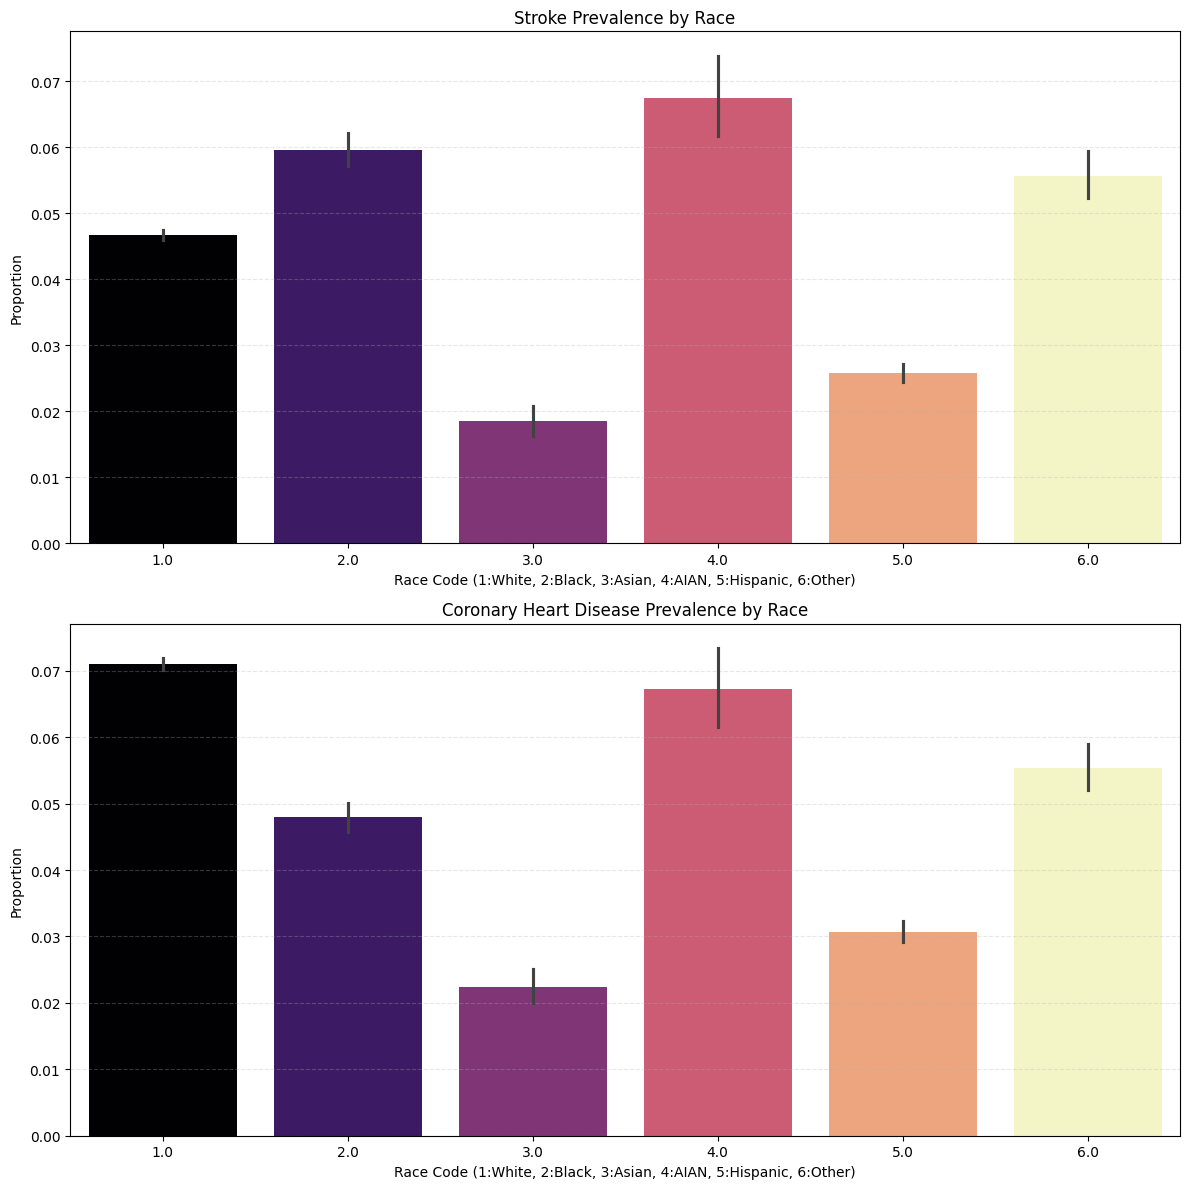

In [15]:


# List of other outcomes to plot
outcomes = {'CVDSTRK3': 'Stroke', 'CVDCRHD4': 'Coronary Heart Disease'}

# Set up the figure for multiple subplots
fig, axes = plt.subplots(nrows=len(outcomes), ncols=1, figsize=(12, 12))

for i, (col, title) in enumerate(outcomes.items()):
    # Drop NaNs for the specific outcome and race
    df_plot_loop = df.dropna(subset=[col, '_IMPRACE'])

    # Calculate mean for 'Yes' responses (1.0)
    # Updated to assign 'x' to 'hue' to resolve the FutureWarning
    sns.barplot(data=df_plot_loop, x='_IMPRACE', y=(df_plot_loop[col] == 1.0), ax=axes[i], palette='magma', hue='_IMPRACE', legend=False)

    axes[i].set_title(f'{title} Prevalence by Race')
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel('Race Code (1:White, 2:Black, 3:Asian, 4:AIAN, 5:Hispanic, 6:Other)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Unadjusted prevalence of stroke and CHD shows a race gradient slightly similar to heart attack, though not identical.


### 7.5 All CVD outcomes by race — side-by-side - **Flanders**


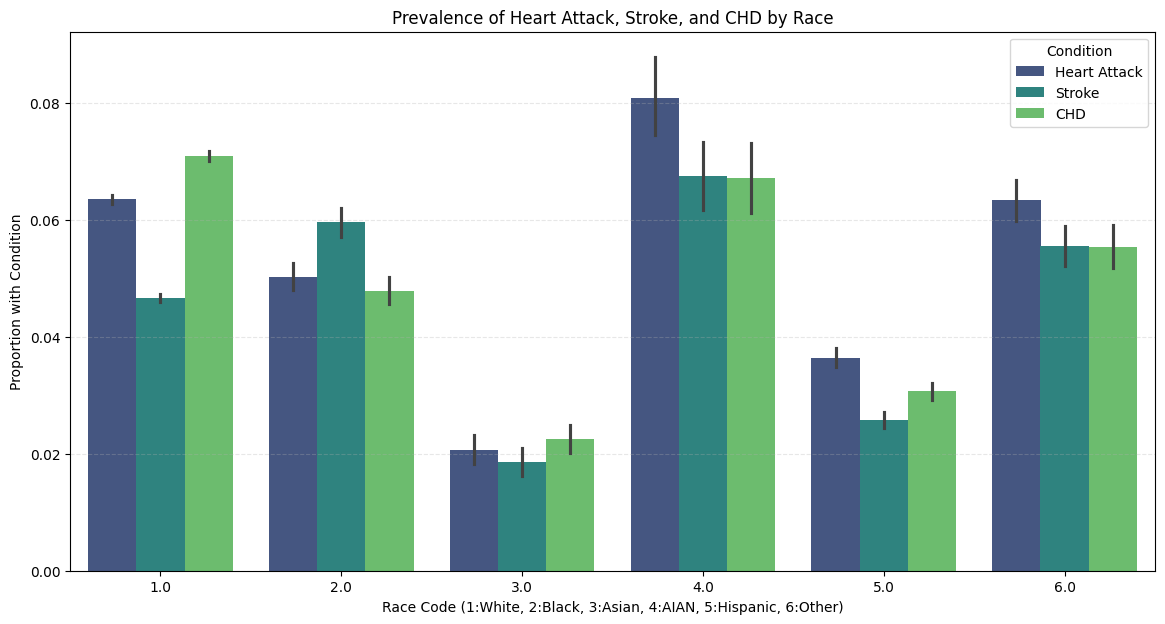

In [16]:


# Prepare data for comparison
outcomes_map = {'CVDINFR4': 'Heart Attack', 'CVDSTRK3': 'Stroke', 'CVDCRHD4': 'CHD'}
comparison_list = []

for col, label in outcomes_map.items():
    temp_df = df.dropna(subset=[col, '_IMPRACE']).copy()
    temp_df['Outcome_Type'] = label
    temp_df['Has_Condition'] = (temp_df[col] == 1.0).astype(int)
    comparison_list.append(temp_df[['_IMPRACE', 'Outcome_Type', 'Has_Condition']])

df_compare = pd.concat(comparison_list)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_compare, x='_IMPRACE', y='Has_Condition', hue='Outcome_Type', palette='viridis')
plt.title('Prevalence of Heart Attack, Stroke, and CHD by Race')
plt.ylabel('Proportion with Condition')
plt.xlabel('Race Code (1:White, 2:Black, 3:Asian, 4:AIAN, 5:Hispanic, 6:Other)')
plt.legend(title='Condition')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Consolidating the three outcomes onto one axis. Patterns are broadly parallel across heart attack, stroke, and CHD; heart attack is the outcome modelled in Section 8.


### 7.6 Interplay: diabetes × race on heart-attack prevalence - **Flanders**

A point plot showing whether the jump in heart-attack prevalence from non-diabetic to diabetic is steeper for some racial groups. This is descriptive evidence of possible interaction; the primary model keeps the main-effects specification for interpretability.


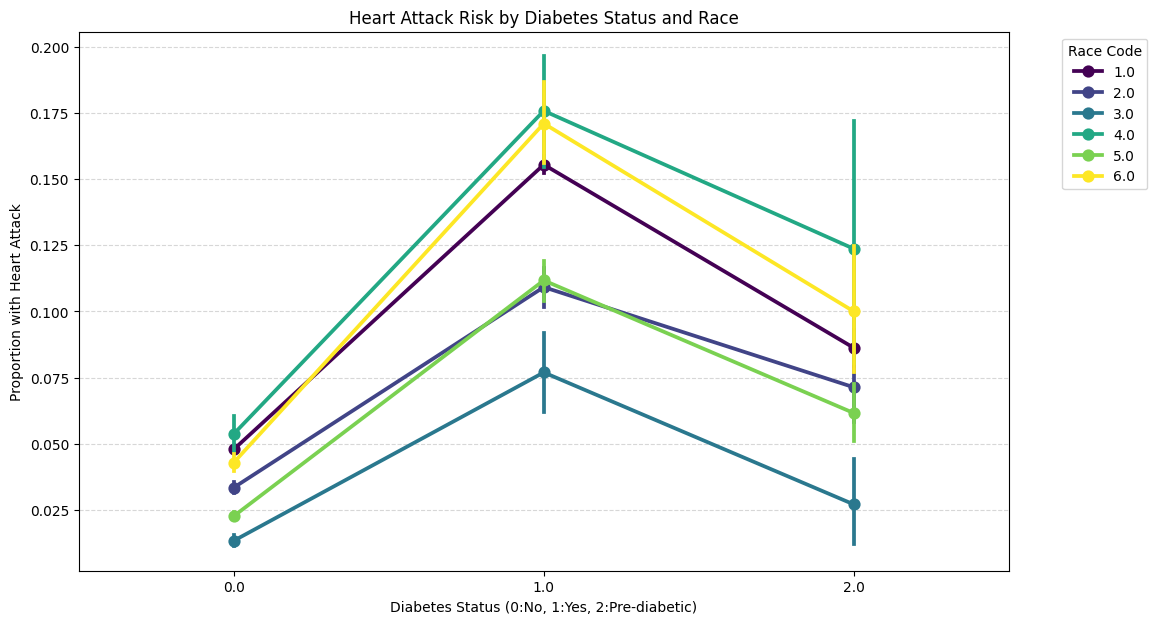

In [17]:
# Filtering out NaNs for the three variables of interest
df_interact = df.dropna(subset=['CVDINFR4', 'diabetes_status', '_IMPRACE'])

# Create a point plot to see the 'slope' of risk across diabetes categories for each race
plt.figure(figsize=(12, 7))
sns.pointplot(data=df_interact,
              x='diabetes_status',
              y=(df_interact['CVDINFR4'] == 1.0),
              hue='_IMPRACE',
              palette='viridis')

plt.title('Heart Attack Risk by Diabetes Status and Race')
plt.ylabel('Proportion with Heart Attack')
plt.xlabel('Diabetes Status (0:No, 1:Yes, 2:Pre-diabetic)')
plt.legend(title='Race Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

The slope from non-diabetic to diabetic is positive and large across every racial group, but the intercept and magnitude differ — some groups start higher and rise further. Formal interaction testing is out of scope for the main model.


## 8. Primary Model — Weighted Logistic Regression - **Flanders**

The centerpiece analysis. Specification:

- **Outcome:** `target` = 1 if `CVDINFR4`=Yes, else 0.
- **Predictors:** `C(_IMPRACE)` (primary exposure, White = reference), `C(diabetes_status)`, `C(smoking_status)`, `C(_AGEG5YR)` (age group as categorical to avoid assuming linearity in log-odds across age), `C(SEXVAR)`.
- **Family:** Binomial with logit link (`sm.GLM`).
- **Weights:** `_LLCPWT` normalized to sum to *n* (the analytic sample size), passed as `freq_weights`. Normalization preserves relative weighting while keeping the effective sample size realistic for variance calculation.
- **Standard errors:** cluster-robust on `_PSU` to handle within-PSU correlation induced by the complex survey design.

This approximates `svyglm` (R `survey` package which ultimately is better but we're using python) but does not replicate it — see Section 11 for the specific caveats. statsmodels emits a `SpecificationWarning` that `cov_type` is not fully supported with `freq_weights`; that warning is acknowledged and discussed in limitations.


In [18]:
# Complete-case dataset for the primary model
model_df = df.dropna(subset=[
    'CVDINFR4', 'diabetes_status', '_IMPRACE', 'smoking_status',
    '_AGEG5YR', 'SEXVAR', '_LLCPWT', '_PSU'
]).copy()

model_df['target'] = (model_df['CVDINFR4'] == 1.0).astype(int)

# Normalize weights: preserves relative weighting, keeps N realistic
# (so the variance calc doesn't think we have 258 million observations)
normed_weights = (model_df['_LLCPWT'] / model_df['_LLCPWT'].sum()) * len(model_df)

formula = ('target ~ C(_IMPRACE) + C(diabetes_status) + '
           'C(smoking_status) + C(_AGEG5YR) + C(SEXVAR)')

# GLM with binomial family = logistic regression, but accepts weights
glm_model = sm.GLM.from_formula(
    formula,
    data=model_df,
    family=sm.families.Binomial(),
    freq_weights=normed_weights
)

# Cluster-robust SEs on PSU to handle within-cluster correlation
result = glm_model.fit(
    cov_type='cluster',
    cov_kwds={'groups': model_df['_PSU'].values}
)

print(f"Analytic N: {len(model_df):,}")
print(result.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


Analytic N: 412,780
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:               412780
Model:                            GLM   Df Residuals:                412756.00
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -63084.
Date:                Fri, 24 Apr 2026   Deviance:                   1.2617e+05
Time:                        19:43:02   Pearson chi2:                 4.09e+05
No. Iterations:                     8   Pseudo R-squ. (CS):            0.05404
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
In

### 8.1 Odds ratios and 95% confidence intervals _ **Scruggs**

Coefficients exponentiated to the odds-ratio scale. The outcome has ~5.9% prevalence in the sample, so ORs approximate relative risks numerically — but the interpretation language should remain on the odds scale ("odds of reporting a heart attack are X times…").


In [19]:
# Calculate Odds Ratios and 95% Confidence Intervals
odds_ratios = np.exp(result.params)
conf = np.exp(result.conf_int())
conf['Odds Ratio'] = odds_ratios
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
conf = conf[['Odds Ratio', '2.5%', '97.5%']]

print("=== Odds Ratios and 95% Confidence Intervals (Primary Model) ===")
display(conf.round(4))


=== Odds Ratios and 95% Confidence Intervals (Primary Model) ===


,Odds Ratio,2.5%,97.5%
Intercept,0.0058,0.0042,0.0081
C(_IMPRACE)[T.2.0],0.9601,0.8528,1.0809
C(_IMPRACE)[T.3.0],0.5345,0.3866,0.7390
C(_IMPRACE)[T.4.0],1.4781,1.1573,1.8879
C(_IMPRACE)[T.5.0],0.9930,0.8808,1.1195
C(_IMPRACE)[T.6.0],1.3281,1.1210,1.5735
C(diabetes_status)[T.1.0],2.6206,2.4405,2.8140
C(diabetes_status)[T.2.0],1.5913,1.3169,1.9230
C(smoking_status)[T.2.0],1.6889,1.5719,1.8146
C(smoking_status)[T.3.0],2.3468,2.0393,2.7006


**Race coefficient interpretation (primary model).** Reference category = White, Non-Hispanic. The ORs on `C(_IMPRACE)[T.k]` describe the odds of self-reported heart attack for group *k* relative to White, **after** adjusting for age group, sex, diabetes status, and smoking status. These are *residual* associations — they do not capture the parts of racial disparity that operate *through* diabetes and smoking, which are themselves shaped by structural factors.


## 9. Unweighted Comparison - **Scruggs**

To show why design-weighting matters, we refit the same specification as an ordinary (unweighted) logistic regression with no cluster adjustment, using `sm.Logit`. Differences between the two sets of race coefficients indicate the extent to which ignoring the BRFSS complex survey design would have biased inference.


In [20]:
# Unweighted logistic regression — identical formula, no weights,
# no cluster-robust SEs. This is what you get if you ignore design.
unweighted_model = sm.Logit.from_formula(formula, data=model_df)
unweighted_result = unweighted_model.fit(disp=0)

print(f"Analytic N: {len(model_df):,}")
print(unweighted_result.summary())


Analytic N: 412,780
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               412780
Model:                          Logit   Df Residuals:                   412756
Method:                           MLE   Df Model:                           23
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.1357
Time:                        19:43:13   Log-Likelihood:                -80025.
converged:                       True   LL-Null:                       -92592.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -5.4139      0.094    -57.318      0.000      -5.599      -5.229
C(_IMPRACE)[T.2.0]           -0.0753      0.028     -2.652      0.

### 9.1 Race coefficients — weighted vs unweighted - **Scruggs**


In [21]:
def race_or_table(res):
    """Extract ORs and 95% CIs for race coefficients."""
    idx = [k for k in res.params.index if '_IMPRACE' in k]
    ci = res.conf_int()
    return pd.DataFrame({
        'OR':      np.exp(res.params[idx]).round(3),
        'CI 2.5%': np.exp(ci.loc[idx, 0]).round(3),
        'CI 97.5%': np.exp(ci.loc[idx, 1]).round(3),
    })

race_labels = {
    'C(_IMPRACE)[T.2.0]': 'Black, NH',
    'C(_IMPRACE)[T.3.0]': 'Asian, NH',
    'C(_IMPRACE)[T.4.0]': 'AI/AN, NH',
    'C(_IMPRACE)[T.5.0]': 'Hispanic',
    'C(_IMPRACE)[T.6.0]': 'Other, NH',
}

weighted_tbl = race_or_table(result).rename(index=race_labels)
unweighted_tbl = race_or_table(unweighted_result).rename(index=race_labels)

comparison = pd.concat(
    {'Weighted (primary)': weighted_tbl,
     'Unweighted':         unweighted_tbl},
    axis=1
)

print("=== Race odds ratios: weighted primary model vs unweighted ===")
print("(Reference group: White, Non-Hispanic)")
display(comparison)


=== Race odds ratios: weighted primary model vs unweighted ===
(Reference group: White, Non-Hispanic)


Weighted (primary)                  Unweighted                 
                          OR CI 2.5% CI 97.5%         OR CI 2.5% CI 97.5%
Black, NH              0.960   0.853    1.081      0.927   0.877    0.981
Asian, NH              0.535   0.387    0.739      0.569   0.496    0.653
AI/AN, NH              1.478   1.157    1.888      1.430   1.294    1.581
Hispanic               0.993   0.881    1.120      1.073   1.014    1.134
Other, NH              1.328   1.121    1.573      1.267   1.181    1.360

Differences between the two columns reflect the influence of the BRFSS design weights on point estimates and the effect of the cluster-robust variance adjustment on CI widths. The weighted model is reported as primary because BRFSS is a complex survey and the weights correct for differential selection and non-response that would otherwise bias population-level inference.


## 10. Sensitivity Analysis — SES adjustment - **Scruggs**

We refit the primary model adding education (`EDUCA`) and income (`INCOME3`) as ordinal continuous covariates. The question is whether the race coefficients attenuate once SES is held constant.

**Caveats this sensitivity adds:**

- `INCOME3` is ~20% missing, so the analytic N drops noticeably. The two models are therefore fit on different samples — not strictly nested — which is itself something to read carefully.
- Adjusting for SES when SES is on the causal pathway from race to cardiovascular outcomes will *mechanically* attenuate the race coefficient. Attenuation here should not be interpreted as evidence that race "doesn't matter" — it reflects that part of the disparity operates through the SES channel.


In [22]:
# Sensitivity model — primary spec plus EDUCA + INCOME3 as ordinal continuous.
sensitivity_df = df.dropna(subset=[
    'CVDINFR4', 'diabetes_status', '_IMPRACE', 'smoking_status',
    '_AGEG5YR', 'SEXVAR', '_LLCPWT', '_PSU', 'EDUCA', 'INCOME3'
]).copy()

sensitivity_df['target'] = (sensitivity_df['CVDINFR4'] == 1.0).astype(int)

sens_weights = (sensitivity_df['_LLCPWT'] / sensitivity_df['_LLCPWT'].sum()) * len(sensitivity_df)

sens_formula = ('target ~ C(_IMPRACE) + C(diabetes_status) + '
                'C(smoking_status) + C(_AGEG5YR) + C(SEXVAR) + '
                'EDUCA + INCOME3')

sens_glm = sm.GLM.from_formula(
    sens_formula,
    data=sensitivity_df,
    family=sm.families.Binomial(),
    freq_weights=sens_weights
)

sens_result = sens_glm.fit(
    cov_type='cluster',
    cov_kwds={'groups': sensitivity_df['_PSU'].values}
)

print(f"Primary analytic N:     {len(model_df):,}")
print(f"Sensitivity analytic N: {len(sensitivity_df):,} "
      f"(drop of {len(model_df) - len(sensitivity_df):,} from INCOME3/EDUCA missingness)")
print(sens_result.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


Primary analytic N:     412,780
Sensitivity analytic N: 346,717 (drop of 66,063 from INCOME3/EDUCA missingness)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:               346717
Model:                            GLM   Df Residuals:                   346691
Model Family:                Binomial   Df Model:                           25
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -51885.
Date:                Fri, 24 Apr 2026   Deviance:                   1.0377e+05
Time:                        19:43:27   Pearson chi2:                 3.31e+05
No. Iterations:                     8   Pseudo R-squ. (CS):            0.05931
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
----

### 10.1 Race coefficients — primary vs SES-adjusted - **Scruggs**


In [23]:
# Side-by-side race ORs: primary (no SES) vs sensitivity (+ EDUCA, INCOME3)
primary_tbl = race_or_table(result).rename(index=race_labels)
sens_tbl    = race_or_table(sens_result).rename(index=race_labels)

ses_comparison = pd.concat(
    {'Primary (no SES)':   primary_tbl,
     'Sensitivity (+SES)': sens_tbl},
    axis=1
)

print("=== Race odds ratios: primary vs SES-adjusted ===")
print("(Reference group: White, Non-Hispanic; SES = EDUCA + INCOME3, ordinal)")
display(ses_comparison)


=== Race odds ratios: primary vs SES-adjusted ===
(Reference group: White, Non-Hispanic; SES = EDUCA + INCOME3, ordinal)


Primary (no SES)                  Sensitivity (+SES)          \
                        OR CI 2.5% CI 97.5%                 OR CI 2.5%   
Black, NH            0.960   0.853    1.081              0.793   0.695   
Asian, NH            0.535   0.387    0.739              0.541   0.369   
AI/AN, NH            1.478   1.157    1.888              1.229   0.928   
Hispanic             0.993   0.881    1.120              0.694   0.601   
Other, NH            1.328   1.121    1.573              1.221   1.007   

                    
          CI 97.5%  
Black, NH    0.906  
Asian, NH    0.793  
AI/AN, NH    1.627  
Hispanic     0.801  
Other, NH    1.480

Compare the two OR columns for each racial group. Attenuation toward 1.0 after adding SES indicates that part of the residual race association in the primary model was operating through education and income. OR movement *away* from 1.0 or near-no change indicates the race association is not well explained by SES measured this way. Neither pattern should be read as the "real" answer — both models are informative, and both are subject to the framing caveats in Section 11.


## 11. Limitations - **All**

### Survey-design approximation is not full `svyglm`

The primary model uses normalized `freq_weights` plus cluster-robust SEs on `_PSU` — a commonly used statsmodels approximation of `svyglm`. It is **not** equivalent to a full survey-package fit:

- **Stratification is not incorporated into the variance calculation.** BRFSS uses `_STSTR` to define strata; the variance estimator here treats the design as clustered but unstratified, which is typically conservative (slightly inflated SEs) but is not the textbook Taylor-series survey variance.
- **statsmodels emits a `SpecificationWarning`** that `cov_type` is not fully supported with `freq_weights`. Empirically the resulting SEs are reasonable, but this combination is not formally validated in statsmodels, and a production analysis should cross-check against `survey::svyglm` in R or `statsmodels.survey` extensions.

### Outcome is self-reported

`CVDINFR4` asks whether a respondent has *ever been told* they had a heart attack. This depends on healthcare access (diagnosis requires a provider contact), recall, and willingness to report. Differential under-reporting by race is plausible, and would bias OR estimates toward or away from the null depending on direction.

### Race is a social / structural variable, not biological

Race categories in BRFSS reflect self-identification plus CDC imputation. Coefficients on `C(_IMPRACE)` should be interpreted as summaries of how membership in a racialized group in the US relates to the outcome — capturing the downstream effects of structural factors (residential segregation, healthcare access, occupational exposure, chronic stress) — not as biological differences. Adjusted coefficients measure *residual* association after controlling for variables (diabetes, smoking, later SES) that are themselves patterned by racialization, so **total** disparities are substantially larger than the conditional estimates reported.

### Rare-outcome framing: use odds, not risk

Heart-attack prevalence in this sample is ~5.9%. With a rare outcome the odds ratio numerically approximates the risk ratio, which is often used to motivate informal "risk" language. **The interpretation language in this notebook stays on the odds scale** ("odds of reporting heart attack") to remain technically correct and to avoid implying a prospective risk-ratio design that the cross-sectional BRFSS does not support.

### Cross-sectional design

BRFSS is a point-in-time survey. All associations reported are cross-sectional; they describe patterns in who currently reports a prior heart-attack diagnosis conditional on current covariate values. Causal language ("caused by", "increases risk of") is not warranted from this design.

### Missingness

The primary model uses complete-case analysis. BMI was excluded as a covariate because its missingness is patterned by race and outcome (Section 5.6). Income is ~20% missing, which is why SES enters only in the sensitivity analysis and only on a smaller analytic sample.


## 12. Conclusion

After adjusting for age, sex, diabetes status, and smoking status, racial/ethnic categories in BRFSS 2024 remain differentially associated with the odds of self-reported heart attack relative to the White, Non-Hispanic reference group. Section 10's SES sensitivity analysis shows how much of that residual association can be further accounted for by education and income — a partial but not complete explanation.

The analysis is best read as a descriptive summary of conditional associations in a complex national survey, not as a causal estimate of the effect of race on cardiovascular disease. The honest interpretation is: conditional disparities exist, SES attenuates them partially, and the cross-sectional self-reported design limits the strength of claims that can be drawn.
